In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================================
# 📊 Obtener datos del Fear & Greed Index de Alternative.me
# ==========================================================
url = "https://api.alternative.me/fng/"
params = {"limit": 5000, "format": "json"}

response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()["data"]
    df = pd.DataFrame(data)

    # Convertir tipos y limpiar
    df["timestamp"] = pd.to_datetime(df["timestamp"].astype(int), unit="s")
    df["value"] = pd.to_numeric(df["value"])
    df = df.rename(columns={
        "timestamp": "Date",
        "value": "FearGreed_Value",
        "value_classification": "FearGreed_Label"
    })
    df = df.sort_values("Date")

    # Guardar
    # Cambia esta ruta por la que prefieras:
    ruta_guardado = "../data/csv/raw/fear_greed_index.csv"

    # Crear carpeta si no existe
    os.makedirs(os.path.dirname(ruta_guardado), exist_ok=True)

    # Guardar el archivo CSV
    df.to_csv(ruta_guardado)
    print("✅ Fear & Greed Index descargado correctamente")
    print(df.head())
else:
    print("❌ Error al obtener datos:", response.status_code, response.text)


✅ Fear & Greed Index descargado correctamente
      FearGreed_Value FearGreed_Label       Date time_until_update
2845               30            Fear 2018-02-01               NaN
2844               15    Extreme Fear 2018-02-02               NaN
2843               40            Fear 2018-02-03               NaN
2842               24    Extreme Fear 2018-02-04               NaN
2841               11    Extreme Fear 2018-02-05               NaN


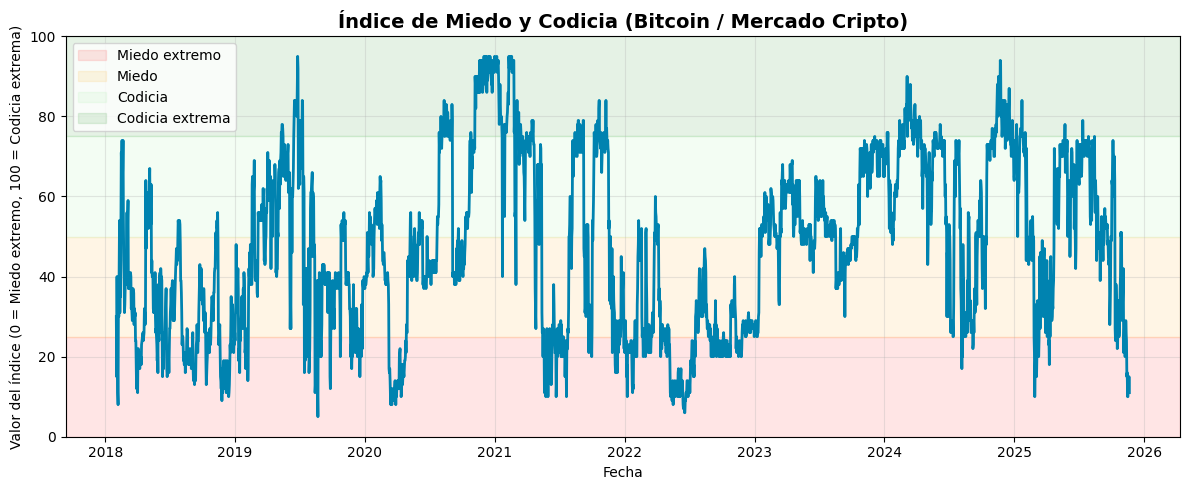

In [59]:
# ==========================================================
# 3️⃣ Gráfica del índice
# ==========================================================
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["FearGreed_Value"], color="#0083B0", linewidth=2)
plt.title("Índice de Miedo y Codicia (Bitcoin / Mercado Cripto)", fontsize=14, weight="bold")
plt.xlabel("Fecha")
plt.ylabel("Valor del índice (0 = Miedo extremo, 100 = Codicia extrema)")
plt.grid(alpha=0.3)
plt.ylim(0, 100)

# Colorear zonas
plt.axhspan(0, 25, color="red", alpha=0.1, label="Miedo extremo")
plt.axhspan(25, 50, color="orange", alpha=0.1, label="Miedo")
plt.axhspan(50, 75, color="lightgreen", alpha=0.1, label="Codicia")
plt.axhspan(75, 100, color="green", alpha=0.1, label="Codicia extrema")

plt.legend()
plt.tight_layout()
plt.show()

Enlace para descargar csv de ethereum, bitcoin histórico, TotalMarketCap, inflación y tipos de interes

https://www.coingecko.com/en/coins/ethereum/historical_data

https://www.coingecko.com/en/charts

https://www.coingecko.com/en/coins/bitcoin/historical_data

https://www.investopedia.com/inflation-rate-by-year-7253832?utm_source=

https://fred.stlouisfed.org/series/FEDFUNDS?utm_source=

Desde el dia 09/11/2017 hasta dia de hoy

In [60]:
import pandas as pd

# ===============================
# 1) Cargar CSVs
# ===============================

btc = pd.read_csv(
    r"C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\data\csv\raw\btc-usd-max.csv",
    names=["snapped_at","btc_price","btc_mcap","btc_volume"],
    header=0
)

eth = pd.read_csv(
    r"C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\data\csv\raw\eth-usd-max.csv",
    names=["snapped_at","eth_price","eth_mcap","eth_volume"],
    header=0
)

total = pd.read_csv(
    r"C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\data\csv\raw\CoinGecko-GlobalCryptoMktCap-2025-11-14.csv",
    names=["snapped_at","total_mcap","total_volume"],
    header=0
)

# ===============================
# 2) Convertir fechas
# ===============================

btc["date"] = pd.to_datetime(btc["snapped_at"]).dt.date
eth["date"] = pd.to_datetime(eth["snapped_at"]).dt.date

# TOTAL tiene timestamps en milisegundos → convertir:
total["date"] = pd.to_datetime(total["snapped_at"], unit="ms").dt.date

# ===============================
# 3) Seleccionar columnas útiles
# ===============================

btc = btc[["date", "btc_mcap"]]
eth = eth[["date", "eth_mcap"]]
total = total[["date", "total_mcap"]]

# ===============================
# 4) Merge OUTER de todo
# ===============================

df = (
    btc.merge(eth, on="date", how="outer")
       .merge(total, on="date", how="outer")
       .sort_values("date")
       .reset_index(drop=True)
)

# ===============================
# 5) Recortar desde que existe ETH
# ===============================

first_eth_date = eth["date"].min()
df = df[df["date"] >= first_eth_date].copy()

# ===============================
# 6) INTERPOLAR total_mcap QUE FALTE
# ===============================

df["total_mcap"] = df["total_mcap"].interpolate(method="linear")

# ===============================
# 7) Calcular dominancias
# ===============================

df["btc_dominance"] = df["btc_mcap"] / df["total_mcap"]
df["eth_dominance"] = df["eth_mcap"] / df["total_mcap"]
df["alt_dominance"] = 1 - df["btc_dominance"] - df["eth_dominance"]

# ===============================
# 8) Guardar dataset final
# ===============================

df.to_csv(
    r"C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\data\csv\raw\dominance_complete.csv",
    index=False
)

print("DONE!")
print(df.head())
print(df.tail())


DONE!
           date      btc_mcap      eth_mcap    total_mcap  btc_dominance  \
829  2015-08-07  4.015651e+09  0.000000e+00  4.661340e+09       0.861480   
830  2015-08-08  3.745911e+09  8.033948e+07  4.458223e+09       0.840225   
831  2015-08-09  3.811338e+09           NaN  4.453010e+09       0.855902   
832  2015-08-10  3.817350e+09  4.155631e+07  4.496843e+09       0.848896   
833  2015-08-11  3.909601e+09  6.453901e+07  4.619966e+09       0.846240   

     eth_dominance  alt_dominance  
829       0.000000       0.138520  
830       0.018021       0.141754  
831            NaN            NaN  
832       0.009241       0.141863  
833       0.013970       0.139790  
            date      btc_mcap      eth_mcap    total_mcap  btc_dominance  \
4577  2025-11-10  2.086419e+12  4.312943e+11  3.620203e+12       0.576327   
4578  2025-11-11  2.112747e+12  4.302720e+11  3.665318e+12       0.576416   
4579  2025-11-12  2.053216e+12  4.119698e+11  3.548053e+12       0.578688   
4580  2025-11

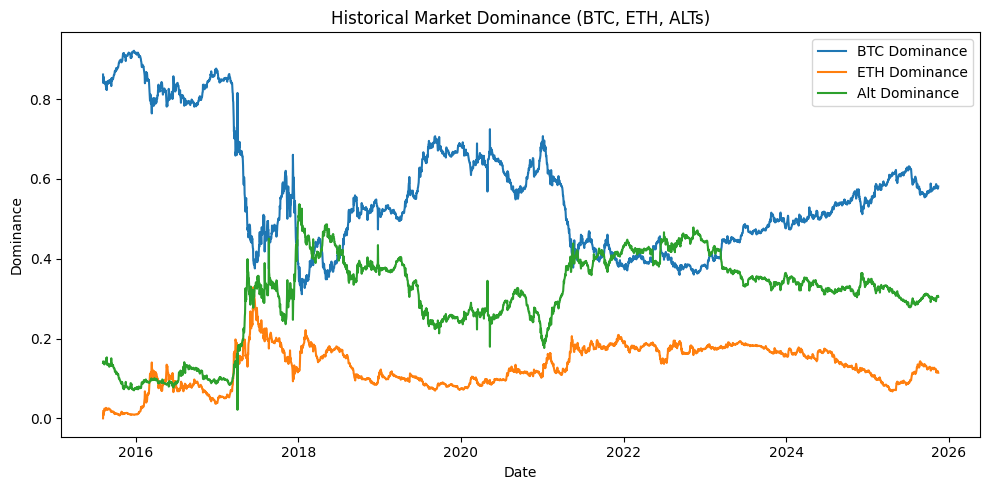

In [61]:


df["date"] = pd.to_datetime(df["date"])

plt.figure(figsize=(10,5))
plt.plot(df["date"], df["btc_dominance"], label="BTC Dominance")
plt.plot(df["date"], df["eth_dominance"], label="ETH Dominance")
plt.plot(df["date"], df["alt_dominance"], label="Alt Dominance")
plt.xlabel("Date")
plt.ylabel("Dominance")
plt.title("Historical Market Dominance (BTC, ETH, ALTs)")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

# URL oficial del CPI mensual USA (CPIAUCSL)
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL"

# Descargar
df = pd.read_csv(url)

print("Columnas encontradas:", df.columns.tolist())

# Detectar columna de fecha automáticamente
date_col = None
for col in df.columns:
    if col.lower() in ["date", "date ", "observation_date"]:
        date_col = col
        break

if date_col is None:
    raise ValueError("❌ No se encontró columna de fecha en el CSV.")

# Convertir a datetime
df["date"] = pd.to_datetime(df[date_col])

# Renombrar CPI
value_col = [c for c in df.columns if c != date_col][0]
df = df.rename(columns={value_col: "cpi"})

# Inflación interanual (%)
df["inflation_12m"] = df["cpi"].pct_change(12) * 100

# Guardar CSV
df.to_csv("../data/csv/raw/us_inflation_cpi_fred.csv", index=False)

print("✅ Datos guardados correctamente.")
print(df.head())
print(df.tail())


Columnas encontradas: ['observation_date', 'CPIAUCSL']
✅ Datos guardados correctamente.
  observation_date    cpi       date  inflation_12m
0       1947-01-01  21.48 1947-01-01            NaN
1       1947-02-01  21.62 1947-02-01            NaN
2       1947-03-01  22.00 1947-03-01            NaN
3       1947-04-01  22.00 1947-04-01            NaN
4       1947-05-01  21.95 1947-05-01            NaN
    observation_date      cpi       date  inflation_12m
940       2025-05-01  320.580 2025-05-01       2.375934
941       2025-06-01  321.500 2025-06-01       2.672683
942       2025-07-01  322.132 2025-07-01       2.731801
943       2025-08-01  323.364 2025-08-01       2.939220
944       2025-09-01  324.368 2025-09-01       3.022700


In [19]:
import pandas as pd

# =============================
# 1. Cargar CSV mensual
# =============================
df = pd.read_csv("us_inflation_cpi_fred.csv")

# Asegurar fecha correcta
df["date"] = pd.to_datetime(df["date"])

# =============================
# 2. Crear un rango diario
# =============================
daily_index = pd.date_range(df["date"].min(), df["date"].max(), freq="D")

# Crear dataframe diario vacío
df_daily = pd.DataFrame({"date": daily_index})

# =============================
# 3. Merge diario con mensual
# =============================
df_daily["month"] = df_daily["date"].dt.to_period("M")
df["month"] = df["date"].dt.to_period("M")

df_daily = df_daily.merge(df[["month", "inflation_12m"]], on="month", how="left")

# =============================
# 4. Forward-fill mensual
# =============================
df_daily["inflation_12m"] = df_daily["inflation_12m"].fillna(method="ffill")

# =============================
# 5. Guardar resultado
# =============================
df_daily = df_daily[["date", "inflation_12m"]]
df_daily.to_csv("../data/csv/raw/us_inflation_daily.csv", index=False)

print("✔ Archivo generado: us_inflation_daily.csv")
print(df_daily.head(40))


✔ Archivo generado: us_inflation_daily.csv
         date  inflation_12m
0  1947-01-01            NaN
1  1947-01-02            NaN
2  1947-01-03            NaN
3  1947-01-04            NaN
4  1947-01-05            NaN
5  1947-01-06            NaN
6  1947-01-07            NaN
7  1947-01-08            NaN
8  1947-01-09            NaN
9  1947-01-10            NaN
10 1947-01-11            NaN
11 1947-01-12            NaN
12 1947-01-13            NaN
13 1947-01-14            NaN
14 1947-01-15            NaN
15 1947-01-16            NaN
16 1947-01-17            NaN
17 1947-01-18            NaN
18 1947-01-19            NaN
19 1947-01-20            NaN
20 1947-01-21            NaN
21 1947-01-22            NaN
22 1947-01-23            NaN
23 1947-01-24            NaN
24 1947-01-25            NaN
25 1947-01-26            NaN
26 1947-01-27            NaN
27 1947-01-28            NaN
28 1947-01-29            NaN
29 1947-01-30            NaN
30 1947-01-31            NaN
31 1947-02-01            NaN


C:\Users\josit\AppData\Local\Temp\ipykernel_59832\2029834016.py:30: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_daily["inflation_12m"] = df_daily["inflation_12m"].fillna(method="ffill")


In [18]:
import pandas as pd

# Cargar dataset
df = pd.read_csv("us_inflation_daily.csv")   # o el archivo que quieras
df["date"] = pd.to_datetime(df["date"])

# Fecha límite
cutoff = pd.to_datetime("2018-02-01")

# Filtrar datos (mantener solo >= cutoff)
df_filtered = df[df["date"] >= cutoff].copy()

# Guardar resultado
df_filtered.to_csv("../data/csv/clean/us_inflation_daily_filtered.csv", index=False)

print("✔ Filtrado completado.")
print("Filas nuevas:", len(df_filtered))
print(df_filtered.head())


✔ Filtrado completado.
Filas nuevas: 2770
            date  inflation_12m
25964 2018-02-01       2.263469
25965 2018-02-02       2.263469
25966 2018-02-03       2.263469
25967 2018-02-04       2.263469
25968 2018-02-05       2.263469


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/csv/clean/crypto_dataset_final.csv")

# Ensure numeric only
numeric_df = df.select_dtypes(include=['float64','int64'])

# Compute correlation with eth_price
corr = numeric_df.corr()["eth_price"].sort_values(ascending=False)

corr


ModuleNotFoundError: No module named 'seaborn'